# Copenhagen Burnout Inventory Validation

## 1 Overview

## 2 Importing Libraries

In [1]:
from pathlib import Path
from statistics import mean
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, confusion_matrix

## 3 Load Solace Pipeline

In [2]:
PROJECT_ROOT = Path.cwd().parents[1]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.ai.multimodal_pipeline import MultimodalPipeline

pipeline = MultimodalPipeline()

print("Project root:", PROJECT_ROOT)
print("Solace pipeline loaded.")

c:\Users\Subathra\OneDrive\Desktop\cm3020_Final_Year_project\CM3020_Final_Year_Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: c:\Users\Subathra\OneDrive\Desktop\cm3020_Final_Year_project\CM3020_Final_Year_Project
Solace pipeline loaded.


## 4 Study Settings

In [3]:
# Set to False once the real form export and recordings are in place.
USE_DUMMY_DATA = True

CBI_FOLDER = PROJECT_ROOT / "data" / "raw" / "cbi_study"
RESPONSES_FILE = CBI_FOLDER / "responses.csv"

# Each recording is expected at: data/raw/cbi_study/{participant}.mp4
# where {participant} matches the "Participant number" in the form.

# Copenhagen Burnout Inventory bands (higher = more burnout)
CBI_HIGH = 75
CBI_MODERATE = 50

# Solace wellbeing bands (higher = better wellbeing)
WELLBEING_HIGH = 67
WELLBEING_MIXED = 34

print("CBI folder:", CBI_FOLDER)
print("Dummy mode:", USE_DUMMY_DATA)

CBI folder: c:\Users\Subathra\OneDrive\Desktop\cm3020_Final_Year_project\CM3020_Final_Year_Project\data\raw\cbi_study
Dummy mode: True


## 5 CBI Scoring

In [4]:
# CBI response -> points. Both the frequency and the degree scales map
# onto the same 0-100 points.
RESPONSE_POINTS = {
    "always": 100,
    "to a very high degree": 100,

    "often": 75,
    "to a high degree": 75,

    "sometimes": 50,
    "somewhat": 50,

    "seldom": 25,
    "to a low degree": 25,

    "to a very low degree": 0,
}

# This form uses 13 items: 6 personal + 7 work-related (no client subscale).
# The last work item ("enough energy for family and friends") is reverse scored.
PERSONAL_COUNT = 6
WORK_COUNT = 7


def response_points(value):
    key = " ".join(str(value).strip().lower().split())

    if key in RESPONSE_POINTS:
        return RESPONSE_POINTS[key]

    # "Never - almost never" appears with several dash / comma variants.
    if key.startswith("never"):
        return 0

    raise ValueError(f"Unrecognised response: {value!r}")


def score_cbi(form_df):
    columns = list(form_df.columns)

    participant_column = next(
        column
        for column in columns
        if "participant" in column.lower()
    )

    # Item columns are everything except the timestamp and participant number,
    # kept in their original left-to-right order.
    item_columns = [
        column
        for column in columns
        if column != participant_column
        and "timestamp" not in column.lower()
        and form_df[column].notna().any()
    ]

    assert len(item_columns) >= PERSONAL_COUNT + WORK_COUNT, (
        "Expected at least 13 CBI item columns, found "
        f"{len(item_columns)}."
    )

    item_columns = item_columns[: PERSONAL_COUNT + WORK_COUNT]

    personal_items = item_columns[:PERSONAL_COUNT]
    work_items = item_columns[PERSONAL_COUNT:]
    reverse_item = item_columns[-1]

    rows = []

    for _, row in form_df.iterrows():
        points = {
            column: response_points(row[column])
            for column in item_columns
        }

        # Reverse the energy item so that more energy = less burnout.
        points[reverse_item] = 100 - points[reverse_item]

        personal_score = mean(points[c] for c in personal_items)
        work_score = mean(points[c] for c in work_items)
        overall_score = mean(points[c] for c in item_columns)

        participant_id = str(row[participant_column]).strip()

        rows.append({
            "participant_id": participant_id,
            "clip": participant_id,
            "personal_burnout": personal_score,
            "work_burnout": work_score,
            "cbi_score": overall_score,
        })

    return pd.DataFrame(rows)

## 6 Load CBI Responses

In [5]:
if USE_DUMMY_DATA:
    # Small synthetic form export so the CBI scoring and the analysis can
    # both be verified before the real responses arrive.
    form_df = pd.DataFrame([
        {
            "Participant number": "P01",
            "q1": "Seldom", "q2": "Seldom", "q3": "Seldom",
            "q4": "Never", "q5": "Seldom", "q6": "Seldom",
            "q7": "To a low degree", "q8": "To a low degree",
            "q9": "To a low degree", "q10": "Seldom",
            "q11": "Seldom", "q12": "Seldom", "q13": "Always",
        },
        {
            "Participant number": "P02",
            "q1": "Sometimes", "q2": "Sometimes", "q3": "Sometimes",
            "q4": "Sometimes", "q5": "Sometimes", "q6": "Sometimes",
            "q7": "Somewhat", "q8": "Somewhat", "q9": "Somewhat",
            "q10": "Sometimes", "q11": "Sometimes", "q12": "Sometimes",
            "q13": "Sometimes",
        },
        {
            "Participant number": "P016",
            "q1": "Always", "q2": "Always", "q3": "Always",
            "q4": "Always", "q5": "Always", "q6": "Always",
            "q7": "To a very high degree", "q8": "To a very high degree",
            "q9": "To a very high degree", "q10": "Always",
            "q11": "Always", "q12": "Always", "q13": "Always",
        },
    ])

else:
    form_df = pd.read_csv(RESPONSES_FILE)

responses_df = score_cbi(form_df)

print("Participants:", len(responses_df))
responses_df.round(2)

Participants: 3


,participant_id,clip,personal_burnout,work_burnout,cbi_score
0,P01,P01,20.83,21.43,21.15
1,P02,P02,50.00,50.00,50.00
2,P016,P016,100.00,85.71,92.31


## 7 Score Recordings with Solace

In [6]:
def solace_wellbeing(clip_path):
    temporary_audio = None

    try:
        temporary_audio = pipeline.extract_audio(str(clip_path))

        transcript = pipeline.transcribe(temporary_audio, "English")

        text_strain = pipeline.text_score(transcript)
        audio_strain = pipeline.audio_score(temporary_audio)
        vision_strain = pipeline.vision_score(str(clip_path))

        visual = pipeline.visual_signals(str(clip_path))
        speech = pipeline.speech_signals(
            transcript, temporary_audio, "English"
        )

        primary_scores = [text_strain, audio_strain, vision_strain]

        supporting_scores = [
            speech["speech_signal"],
            speech["disfluency_signal"],
            speech["lexical_signal"],
            visual["blink_signal"],
            visual["head_signal"],
        ]

        (_, _, full_strain, _) = pipeline.fuse(
            primary_scores, supporting_scores
        )

        return 100 - full_strain * 100

    finally:
        if temporary_audio:
            Path(temporary_audio).unlink(missing_ok=True)

In [7]:
if USE_DUMMY_DATA:
    # Synthetic wellbeing scores so the analysis can be verified now.
    dummy_wellbeing = {"P01": 78.0, "P02": 55.0, "P016": 25.0}

    scores_df = responses_df[["participant_id", "clip"]].copy()
    scores_df["wellbeing_score"] = (
        scores_df["participant_id"].map(dummy_wellbeing)
    )

else:
    score_rows = []

    for _, row in responses_df.iterrows():
        clip_path = CBI_FOLDER / f"{row['clip']}.mp4"

        if not clip_path.exists():
            print("Missing recording:", clip_path.name)
            continue

        print(f"Scoring {clip_path.name}...")

        score_rows.append({
            "participant_id": row["participant_id"],
            "clip": row["clip"],
            "wellbeing_score": solace_wellbeing(clip_path),
        })

    scores_df = pd.DataFrame(score_rows)

scores_df

,participant_id,clip,wellbeing_score
0,P01,P01,78.0
1,P02,P02,55.0
2,P016,P016,25.0


## 8 Merge Solace and CBI Scores

In [8]:
study_df = responses_df.merge(
    scores_df[["participant_id", "wellbeing_score"]],
    on="participant_id",
    how="inner",
)

study_df = study_df.dropna(
    subset=["cbi_score", "wellbeing_score"]
).reset_index(drop=True)

print("Matched participants:", len(study_df))
study_df.round(2)

Matched participants: 3


,participant_id,clip,personal_burnout,work_burnout,cbi_score,wellbeing_score
0,P01,P01,20.83,21.43,21.15,78.0
1,P02,P02,50.00,50.00,50.00,55.0
2,P016,P016,100.00,85.71,92.31,25.0


## 9 Correlation Analysis

In [9]:
pearson = study_df["cbi_score"].corr(
    study_df["wellbeing_score"], method="pearson"
)

spearman = study_df["cbi_score"].corr(
    study_df["wellbeing_score"], method="spearman"
)

correlation_df = pd.DataFrame([
    {"Method": "Pearson", "Correlation": round(pearson, 3)},
    {"Method": "Spearman", "Correlation": round(spearman, 3)},
])

# A negative correlation supports validity:
# higher CBI burnout -> lower Solace wellbeing.
correlation_df

,Method,Correlation
0,Pearson,-0.999
1,Spearman,-1.000


## 10 Band Agreement

In [10]:
def cbi_band(score):
    if score >= CBI_HIGH:
        return "High burnout"
    elif score >= CBI_MODERATE:
        return "Moderate burnout"
    else:
        return "Low burnout"


def expected_wellbeing_band(burnout_band):
    return {
        "High burnout": "Low",
        "Moderate burnout": "Mixed",
        "Low burnout": "High",
    }[burnout_band]


def wellbeing_band(score):
    if score >= WELLBEING_HIGH:
        return "High"
    elif score >= WELLBEING_MIXED:
        return "Mixed"
    else:
        return "Low"


study_df["CBI band"] = study_df["cbi_score"].apply(cbi_band)

study_df["Expected wellbeing band"] = (
    study_df["CBI band"].apply(expected_wellbeing_band)
)

study_df["Solace band"] = (
    study_df["wellbeing_score"].apply(wellbeing_band)
)

study_df[
    [
        "participant_id",
        "personal_burnout",
        "work_burnout",
        "cbi_score",
        "CBI band",
        "wellbeing_score",
        "Solace band",
        "Expected wellbeing band",
    ]
].round(2)

,participant_id,personal_burnout,work_burnout,cbi_score,CBI band,wellbeing_score,Solace band,Expected wellbeing band
0,P01,20.83,21.43,21.15,Low burnout,78.0,High,High
1,P02,50.00,50.00,50.00,Moderate burnout,55.0,Mixed,Mixed
2,P016,100.00,85.71,92.31,High burnout,25.0,Low,Low


In [11]:
agreement = accuracy_score(
    study_df["Expected wellbeing band"],
    study_df["Solace band"],
)

print("Band agreement:", round(agreement, 3))

labels = ["Low", "Mixed", "High"]

agreement_matrix = pd.DataFrame(
    confusion_matrix(
        study_df["Expected wellbeing band"],
        study_df["Solace band"],
        labels=labels,
    ),
    index=[f"Expected {label}" for label in labels],
    columns=[f"Solace {label}" for label in labels],
)

agreement_matrix

Band agreement: 1.0


,Solace Low,Solace Mixed,Solace High
Expected Low,1,0,0
Expected Mixed,0,1,0
Expected High,0,0,1


## 11 Visualisation

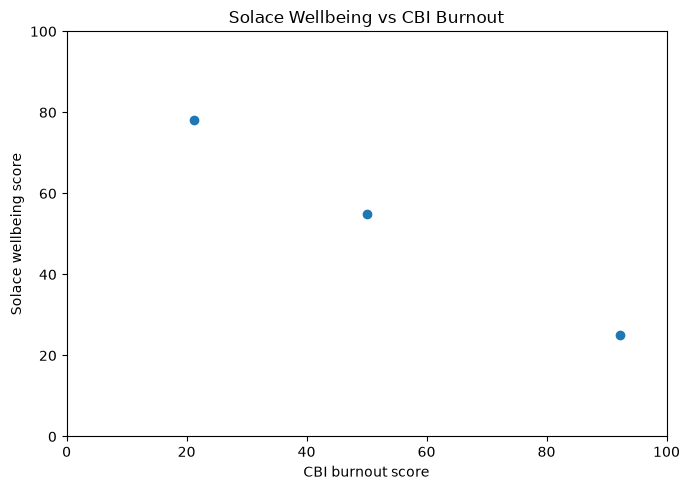

In [12]:
plt.figure(figsize=(7, 5))

plt.scatter(
    study_df["cbi_score"],
    study_df["wellbeing_score"],
)

plt.xlabel("CBI burnout score")
plt.ylabel("Solace wellbeing score")
plt.title("Solace Wellbeing vs CBI Burnout")

plt.xlim(0, 100)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

## 12 Conclusion